# Cat and Dog Classification with K-Fold
Classify images of cats and dogs using Histogram of Oriented Gradients (HOG) for feature extraction.
We will try different classifiers: Decision Tree, Random Forest, Gaussian Naive Bayes, and SVM.
Evaluation is done using Stratified K-Fold Cross Validation.
All images are scaled to [0,1] before feature extraction.

In [36]:
import os
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.transform import resize
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# Load dataset
data_dir = './dataset'
images, labels = [], []

for file in os.listdir(data_dir):
    if file.endswith('.jpg'):
        img_path = os.path.join(data_dir, file)
        
        if file.startswith('cat'):
            labels.append(0)  # Cat
        elif file.startswith('dog'):
            labels.append(1)  # Dog
        else:
            continue

        img = imread(img_path)
        img = rgb2gray(img)  # Convert to grayscale
        img_resized = resize(img, (128, 128), anti_aliasing=True)
        img_resized = img_resized / 255.0  # Scale to [0,1]
        images.append(img_resized)

images = np.array(images)
labels = np.array(labels)
print('Images shape:', images.shape)
print('Labels shape:', labels.shape)
print(f'Number of cats: {np.sum(labels == 0)}')
print(f'Number of dogs: {np.sum(labels == 1)}')

Images shape: (615, 128, 128)
Labels shape: (615,)
Number of cats: 260
Number of dogs: 355


In [38]:
def extract_hog_features(images, visualize=False):
    hog_features = []
    hog_images = [] if visualize else None
    
    for img in images:
        if visualize:
            feat, hog_img = hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2), 
                                orientations=9, visualize=True, block_norm='L2-Hys')
            hog_features.append(feat)
            hog_images.append(hog_img)
        else:
            feat = hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2), 
                       orientations=9, visualize=False, block_norm='L2-Hys')
            hog_features.append(feat)
    
    hog_features = np.array(hog_features)
    hog_images = np.array(hog_images) if visualize else None
    return hog_features, hog_images

In [39]:
# Extract HOG features
hog_features, hog_images = extract_hog_features(images, visualize=True)
print('HOG features shape:', hog_features.shape)

HOG features shape: (615, 8100)


In [40]:
def evaluate_with_kfold(X, y, k=5):
    models = {
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'GaussianNB': GaussianNB(),
        'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42)
    }

    results = {}
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    for name, clf in models.items():
        scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
        results[name] = scores
        print(f"--- {name} ---")
        print(f"Accuracies per fold: {scores}")
        print(f"Mean Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})\n")
    
    return results

In [41]:
# Evaluate all models using K-Fold Cross Validation
results = evaluate_with_kfold(hog_features, labels, k=5)

# Find best model
best_model_name = max(results, key=lambda k: results[k].mean())
print(f"Best Model: {best_model_name}, Accuracy: {results[best_model_name].mean():.4f}")

--- Decision Tree ---
Accuracies per fold: [0.75609756 0.82926829 0.84552846 0.81300813 0.83739837]
Mean Accuracy: 0.8163 (+/- 0.0319)

--- Random Forest ---
Accuracies per fold: [0.93495935 0.95934959 0.95121951 0.94308943 0.93495935]
Mean Accuracy: 0.9447 (+/- 0.0095)

--- GaussianNB ---
Accuracies per fold: [0.89430894 0.87804878 0.89430894 0.92682927 0.85365854]
Mean Accuracy: 0.8894 (+/- 0.0239)

--- SVM (RBF) ---
Accuracies per fold: [0.94308943 0.92682927 0.91056911 0.95934959 0.91056911]
Mean Accuracy: 0.9301 (+/- 0.0190)

Best Model: Random Forest, Accuracy: 0.9447


In [42]:
# Retrain the best model on the full dataset
if best_model_name == 'Decision Tree':
    best_model = DecisionTreeClassifier(random_state=42)
elif best_model_name == 'Random Forest':
    best_model = RandomForestClassifier(n_estimators=100, random_state=42)
elif best_model_name == 'GaussianNB':
    best_model = GaussianNB()
else:
    best_model = SVC(kernel='rbf', probability=True, random_state=42)

best_model.fit(hog_features, labels)
print(f"Retrained {best_model_name} on full dataset.")

Retrained Random Forest on full dataset.


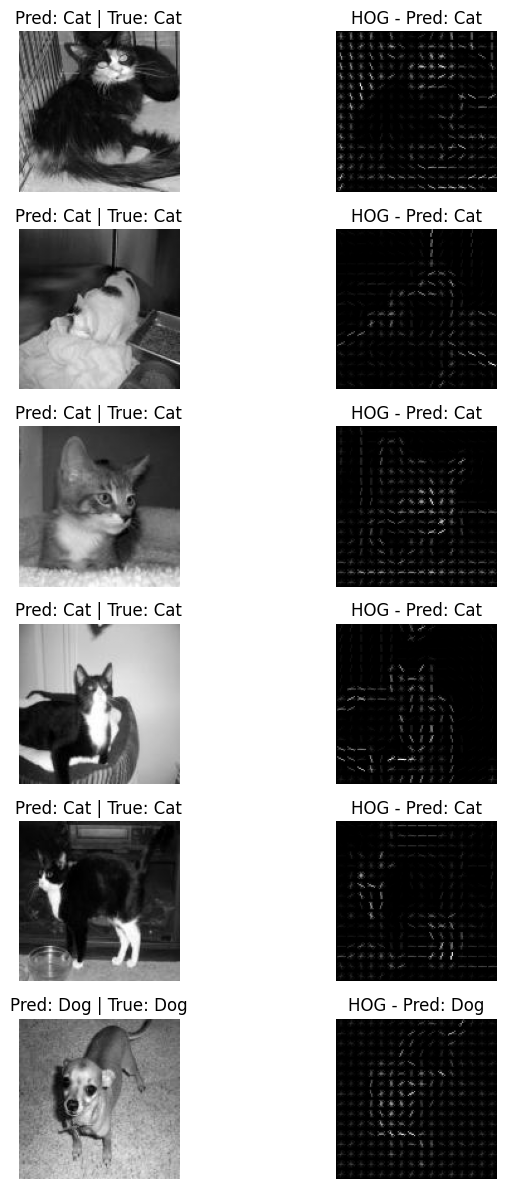

In [43]:
# Show predictions on a few random samples
classes = ['Cat', 'Dog']
sample_indices = np.random.choice(len(images), size=6, replace=False)
y_pred = best_model.predict(hog_features[sample_indices])

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(8, 12))
for i, idx in enumerate(sample_indices):
    ax1 = axes[i, 0]
    true_label = labels[idx]
    pred_label = y_pred[i]
    ax1.imshow(images[idx], cmap='gray')
    ax1.set_title(f'Pred: {classes[pred_label]} | True: {classes[true_label]}')
    ax1.axis('off')

    ax2 = axes[i, 1]
    ax2.imshow(hog_images[idx], cmap='gray')
    ax2.set_title(f'HOG - Pred: {classes[pred_label]}')
    ax2.axis('off')

plt.tight_layout()
plt.show()